In [ ]:
!unzip /content/dataset.zip

Archive:  /content/dataset.zip
   creating: Non-Comp-cropped/
   creating: Non-Comp-cropped/100x/
  inflating: Non-Comp-cropped/100x/1.tif  
  inflating: Non-Comp-cropped/100x/11.tif  
  inflating: Non-Comp-cropped/100x/12.tif  
  inflating: Non-Comp-cropped/100x/13.tif  
  inflating: Non-Comp-cropped/100x/14.tif  
  inflating: Non-Comp-cropped/100x/15.tif  
  inflating: Non-Comp-cropped/100x/16.tif  
  inflating: Non-Comp-cropped/100x/17.tif  
  inflating: Non-Comp-cropped/100x/2.tif  
  inflating: Non-Comp-cropped/100x/3.tif  
  inflating: Non-Comp-cropped/100x/4.tif  
  inflating: Non-Comp-cropped/100x/5.tif  
  inflating: Non-Comp-cropped/100x/6.tif  
  inflating: Non-Comp-cropped/100x/7.tif  
  inflating: Non-Comp-cropped/100x/8.tif  
   creating: Non-Comp-cropped/200x/
  inflating: Non-Comp-cropped/200x/10.tif  
  inflating: Non-Comp-cropped/200x/9.tif  
   creating: Comp-cropped/
   creating: Comp-cropped/100x/
  inflating: Comp-cropped/100x/10.tif  
  inflating: Comp-cropped/10

In [ ]:
import os, random
from pathlib import Path
from PIL import Image
import numpy as np
import albumentations as A

BASE = Path("/content/sample_data/dataset")
FOLDERS = {
    "comp_100x": BASE/"Comp-cropped"/"100x",
    "comp_200x": BASE/"Comp-cropped"/"200x",
    "noncomp_100x": BASE/"Non-Comp-cropped"/"100x",
    "noncomp_200x": BASE/"Non-Comp-cropped"/"200x",
}
OUT_BASE = Path("/content/sample_data/dataset_augmented")
OUT_BASE.mkdir(parents=True, exist_ok=True)

pipeline = A.Compose([
    A.RandomResizedCrop(size=(224,224), scale=(0.7,1.0), ratio=(0.75,1.33), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120*0.05, alpha_affine=120*0.03, p=0.7),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.7),
        A.OpticalDistortion(distort_limit=0.3, shift_limit=0.3, p=0.7),
    ], p=0.7),
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.5),
        A.MotionBlur(blur_limit=3, p=0.5),
    ], p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=15, p=0.5),
    A.CLAHE(clip_limit=4.0, p=0.5),
    A.RandomGamma(gamma_limit=(80,120), p=0.5),
    A.Sharpen(alpha=(0.2,0.5), lightness=(0.5,1.0), p=0.5),
])

for name, src in FOLDERS.items():
    out_dir = OUT_BASE/name
    out_dir.mkdir(parents=True, exist_ok=True)
    tifs = list(src.glob("*.tif"))
    if not tifs:
        raise FileNotFoundError(f"No .tif files in {src}")
    for i in range(100):
        img = np.array(Image.open(random.choice(tifs)).convert("RGB"))
        aug = pipeline(image=img)["image"]
        Image.fromarray(aug).save(out_dir/f"aug_{i:03d}.png")
    print(f"✅ {name}: 100 images saved → {out_dir}")


/tmp/ipython-input-2-1804091242.py:23: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120*0.05, alpha_affine=120*0.03, p=0.7),
/tmp/ipython-input-2-1804091242.py:25: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.3, shift_limit=0.3, p=0.7),
/tmp/ipython-input-2-1804091242.py:28: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),


✅ comp_100x: 100 images saved → /content/sample_data/dataset_augmented/comp_100x
✅ comp_200x: 100 images saved → /content/sample_data/dataset_augmented/comp_200x
✅ noncomp_100x: 100 images saved → /content/sample_data/dataset_augmented/noncomp_100x
✅ noncomp_200x: 100 images saved → /content/sample_data/dataset_augmented/noncomp_200x


In [ ]:
import numpy as np
import cv2
import glob
from math import log10, sqrt
from pathlib import Path

def compute_mae(a, b):
    return float(np.mean(np.abs(a - b)))

def compute_mse(a, b):
    return float(np.mean((a - b) ** 2))

def compute_psnr(a, b, max_val=1.0):
    mse = compute_mse(a, b)
    return float('inf') if mse == 0 else 20 * log10(max_val / sqrt(mse))

orig_base = Path("/content/sample_data/dataset")
aug_base  = Path("/content/sample_data/dataset_augmented")

FOLDERS = {
    "comp_100x":    "Comp-cropped/100x",
    "comp_200x":    "Comp-cropped/200x",
    "noncomp_100x": "Non-Comp-cropped/100x",
    "noncomp_200x": "Non-Comp-cropped/200x",
}

print(f"{'Class':<15} {'MAE':>8} {'MSE':>10} {'PSNR':>10}")
print("-"*45)

for name, rel in FOLDERS.items():
    orig_dir = orig_base / rel
    aug_dir  = aug_base  / name

    orig_paths = sorted(glob.glob(str(orig_dir / "*.tif")))
    aug_paths  = sorted(glob.glob(str(aug_dir  / "*.png")))

    n = min(len(orig_paths), len(aug_paths))
    if n == 0:
        print(f"{name:<15} NO IMAGES!")
        continue

    maes, mses, psnrs = [], [], []
    for i in range(n):
        o = cv2.imread(orig_paths[i], cv2.IMREAD_COLOR).astype(np.float32) / 255.0
        a = cv2.imread(aug_paths[i] , cv2.IMREAD_COLOR).astype(np.float32) / 255.0

        if a.shape != o.shape:
            a = cv2.resize(a, (o.shape[1], o.shape[0]), interpolation=cv2.INTER_LINEAR)

        maes.append(compute_mae(o, a))
        mses.append(compute_mse(o, a))
        psnrs.append(compute_psnr(o, a))

    print(f"{name:<15} "
          f"{np.mean(maes):8.4f} "
          f"{np.mean(mses):10.6f} "
          f"{np.mean(psnrs):10.2f}")


Class                MAE        MSE       PSNR
---------------------------------------------
comp_100x         0.3659   0.197933       7.10
comp_200x         0.3347   0.169499       7.76
noncomp_100x      0.3217   0.160166       7.98
noncomp_200x      0.3241   0.158628       8.01


In [ ]:
import os, numpy as np, random
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19, ResNet50, InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

base_dir = '/content/sample_data/dataset_augmented'
classes = ['comp_100x', 'comp_200x', 'noncomp_100x', 'noncomp_200x']
img_size = (224, 224)
batch_size = 4
input_shape = (img_size[0], img_size[1], 3)
epochs = 30
fine_tune_epochs = 10

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.25
)

train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    classes=classes,
    seed=42
)

val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    classes=classes,
    seed=42,
    shuffle=False
)

y_classes = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_classes),
    y=y_classes
)
class_weight_dict = dict(enumerate(class_weights))

def create_model(base_model_fn, input_shape):
    base = base_model_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.6)(x)
    output = Dense(4, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=output)
    return model, base

models = {'VGG19': VGG19, 'ResNet50': ResNet50, 'InceptionV3': InceptionV3}
results = {}
histories = {}

for name, base_model_fn in models.items():
    model, base = create_model(base_model_fn, input_shape)
    model.compile(optimizer=Adam(1e-4),loss='categorical_crossentropy',metrics=['accuracy'])
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ModelCheckpoint(f'/content/drive/MyDrive/best_{name}.keras',monitor='val_accuracy',save_best_only=True,mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
    ]
    history1 = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )
    base.trainable = True
    for layer in base.layers[:int(len(base.layers) * 0.8)]:
        layer.trainable = False
    model.compile(optimizer=Adam(1e-5),loss='categorical_crossentropy',metrics=['accuracy'])
    history2 = model.fit(
        train_generator,
        epochs=fine_tune_epochs,
        validation_data=val_generator,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )
    full_history = {
        'loss': history1.history['loss'] + history2.history['loss'],
        'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
        'val_loss': history1.history['val_loss'] + history2.history['val_loss'],
        'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy']
    }
    histories[name] = full_history
    best_model = load_model(f'/content/drive/MyDrive/best_{name}.keras')
    val_loss, val_acc = best_model.evaluate(val_generator, verbose=0)
    results[name] = {'val_loss': val_loss, 'val_acc': val_acc}

plt.figure(figsize=(10,6))
model_names = list(results.keys())
accuracies = [results[m]['val_acc'] for m in model_names]
plt.bar(model_names, accuracies, color=['blue','green','red'])
plt.ylim([0,1])
plt.title('Model Comparison - Validation Accuracy')
plt.xlabel('Models')
plt.ylabel('Validation Accuracy')
for i, acc in enumerate(accuracies):
    plt.text(i, acc+0.02, f"{acc:.2%}", ha='center')
plt.savefig('/content/drive/MyDrive/model_comparison.png')
plt.show()

plt.figure(figsize=(15,10))
for name, history in histories.items():
    plt.plot(history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/val_accuracy_comparison.png')

plt.figure(figsize=(15,10))
for name, history in histories.items():
    plt.plot(history['val_loss'], label=name)
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/val_loss_comparison.png')
plt.close()

print("\nFINAL RESULTS")
for name, res in results.items():
    print(f"{name}: Accuracy: {res['val_acc']:.2%}, Loss: {res['val_loss']:.4f}")

model_names = ['VGG19', 'ResNet50', 'InceptionV3']
for name in model_names:
    model = load_model(f'/content/drive/MyDrive/best_{name}.keras')
    val_preds = np.argmax(model.predict(val_generator), axis=1)
    true_classes = val_generator.classes
    cm = confusion_matrix(true_classes, val_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f'/content/drive/MyDrive/confusion_matrix_{name}.png')
    plt.show()
    print(f"{name} Classification Report:")
    print(classification_report(true_classes, val_preds, target_names=classes))

model_vgg = load_model('/content/drive/MyDrive/best_VGG19.keras')
model_resnet = load_model('/content/drive/MyDrive/best_ResNet50.keras')
model_incep = load_model('/content/drive/MyDrive/best_InceptionV3.keras')

pred_vgg = model_vgg.predict(val_generator)
pred_resnet = model_resnet.predict(val_generator)
pred_incep = model_incep.predict(val_generator)

final_preds = np.array([
    np.bincount([np.argmax(p1), np.argmax(p2), np.argmax(p3)]).argmax()
    for p1, p2, p3 in zip(pred_vgg, pred_resnet, pred_incep)
])

true_labels = val_generator.classes

cm = confusion_matrix(true_labels, final_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('/content/drive/MyDrive/ensemble_confusion_matrix.png')
plt.show()

print("Ensemble Classification Report:\n")
print(classification_report(true_labels, final_preds, target_names=classes))


Found 300 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.2559 - loss: 1.7478 - val_accuracy: 0.5100 - val_loss: 1.2516 - learning_rate: 1.0000e-04
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.3988 - loss: 1.2908 - val_accuracy: 0.6900 - val_loss: 1.1342 - learning_rate: 1.0000e-04
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.4298 - loss: 1.2427 - val_accuracy: 0.7300 - val_loss: 1.0136 - learning_rate: 1.0000e-04
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.4991 - loss: 1.1045 - val_accuracy: 0.8000 - val_loss: 0.9368 - learning_rate: 1.0000e-04
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.5488 - loss: 1.0537 - val_accuracy: 0.7500 - val_loss: 0.8796 - learning_rate: 1.0000e-04
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.5799 - loss: 0.9679 - 

KeyboardInterrupt: 

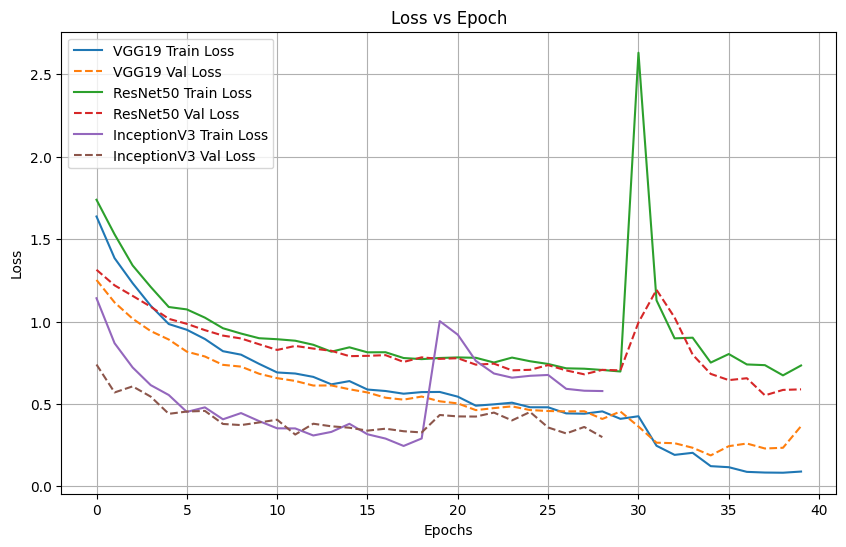

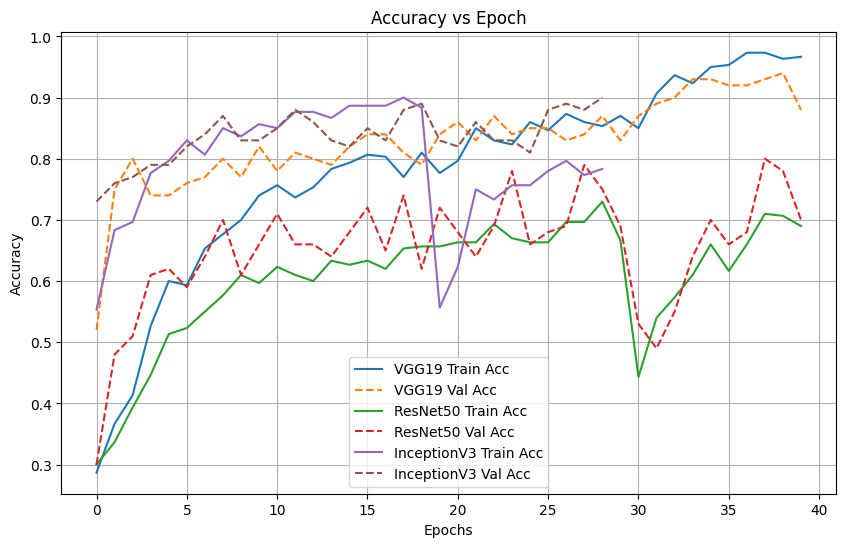

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step


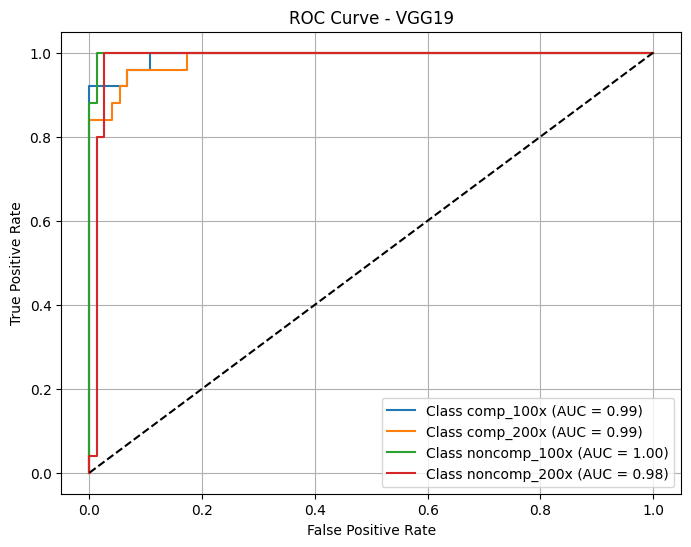

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step


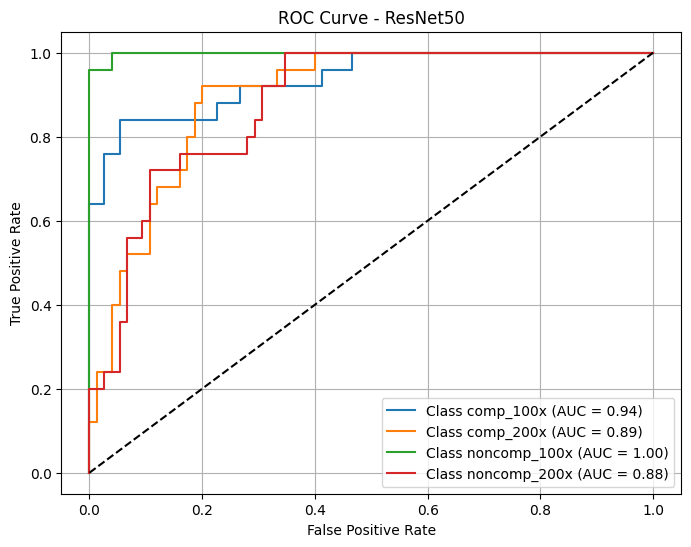

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step


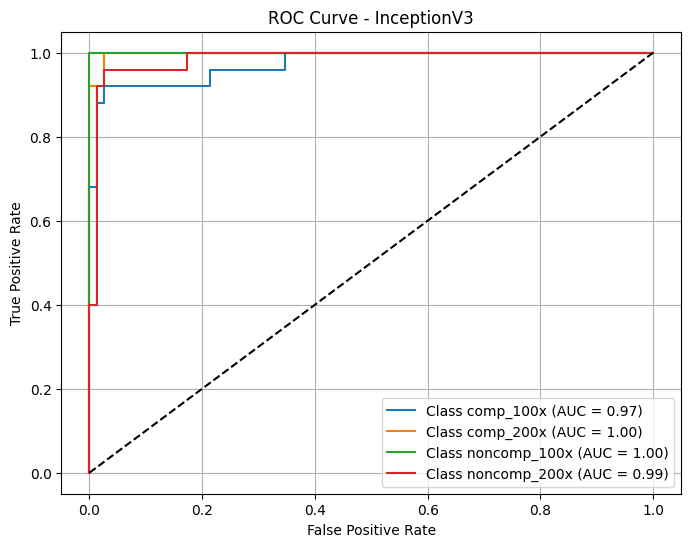

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step


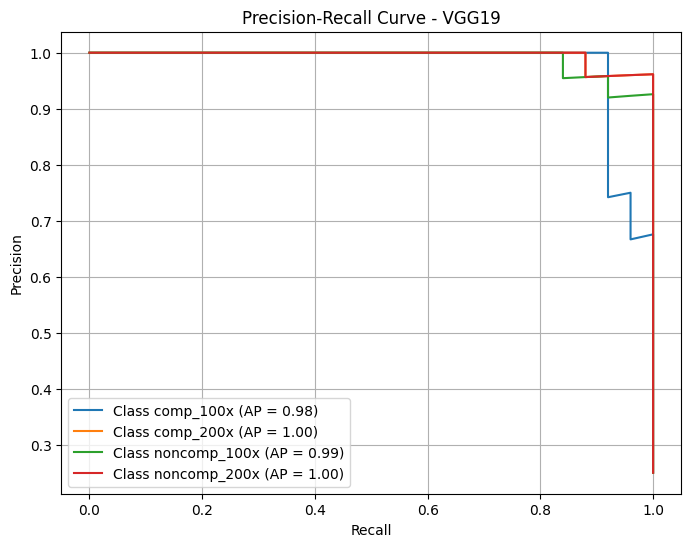

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step


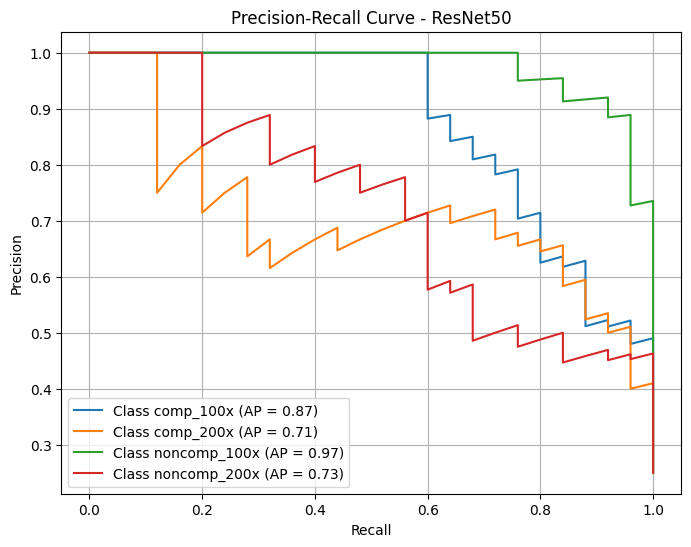

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step


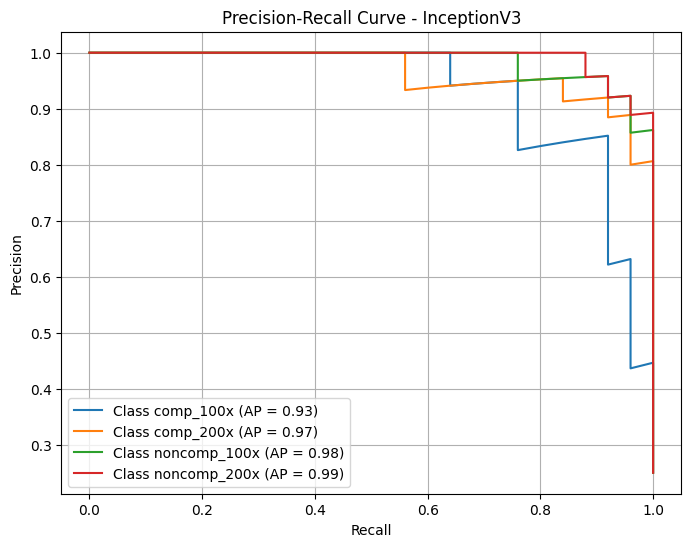

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step


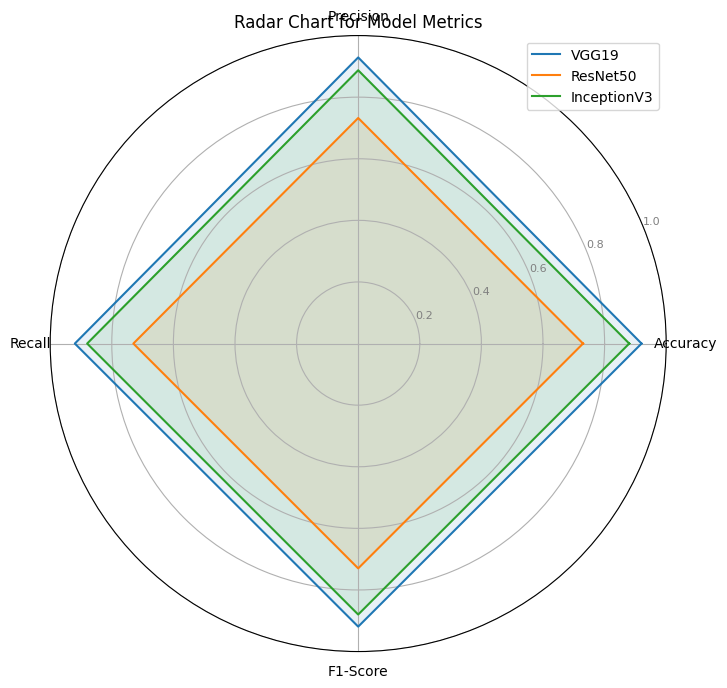

In [ ]:
plt.figure(figsize=(10,6))
for name, history in histories.items():
    plt.plot(history['loss'], label=f'{name} Train Loss')
    plt.plot(history['val_loss'], label=f'{name} Val Loss', linestyle='--')
plt.title('Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/loss_vs_epoch.png')
plt.show()

plt.figure(figsize=(10,6))
for name, history in histories.items():
    plt.plot(history['accuracy'], label=f'{name} Train Acc')
    plt.plot(history['val_accuracy'], label=f'{name} Val Acc', linestyle='--')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/accuracy_vs_epoch.png')
plt.show()

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = len(classes)
true_labels_bin = label_binarize(val_generator.classes, classes=range(n_classes))

for name in model_names:
    model = load_model(f'/content/drive/MyDrive/best_{name}.keras')
    y_score = model.predict(val_generator)

    plt.figure(figsize=(8,6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(true_labels_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0,1], [0,1], 'k--')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'/content/drive/MyDrive/roc_curve_{name}.png')
    plt.show()

from sklearn.metrics import precision_recall_curve, average_precision_score

for name in model_names:
    model = load_model(f'/content/drive/MyDrive/best_{name}.keras')
    y_score = model.predict(val_generator)

    plt.figure(figsize=(8,6))
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(true_labels_bin[:, i], y_score[:, i])
        ap_score = average_precision_score(true_labels_bin[:, i], y_score[:, i])
        plt.plot(recall, precision, label=f'Class {classes[i]} (AP = {ap_score:.2f})')

    plt.title(f'Precision-Recall Curve - {name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'/content/drive/MyDrive/pr_curve_{name}.png')
    plt.show()

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_data = {}

for name in model_names:
    model = load_model(f'/content/drive/MyDrive/best_{name}.keras')
    preds = np.argmax(model.predict(val_generator), axis=1)
    true = val_generator.classes

    acc = accuracy_score(true, preds)
    prec = precision_score(true, preds, average='macro')
    rec = recall_score(true, preds, average='macro')
    f1 = f1_score(true, preds, average='macro')

    metrics_data[name] = [acc, prec, rec, f1]

df = pd.DataFrame(metrics_data, index=metrics)

labels = np.array(metrics)
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))
for name in model_names:
    values = df[name].tolist()
    values += values[:1]
    plt.polar(angles, values, label=name)
plt.fill(angles, df[model_names[0]].tolist() + [df[model_names[0]].tolist()[0]], alpha=0.1)
plt.fill(angles, df[model_names[1]].tolist() + [df[model_names[1]].tolist()[0]], alpha=0.1)
plt.fill(angles, df[model_names[2]].tolist() + [df[model_names[2]].tolist()[0]], alpha=0.1)

plt.xticks(angles[:-1], labels)
plt.yticks([0.2,0.4,0.6,0.8,1.0], ["0.2","0.4","0.6","0.8","1.0"], color="grey", size=8)
plt.title('Radar Chart for Model Metrics')
plt.legend(loc='upper right')
plt.savefig('/content/drive/MyDrive/radar_chart.png')
plt.show()